# Accessing Digital Earth Africa layers for Living Earth Land Cover Classification

This notebook gathers necessary layers to run the Living Earth LCCS workflow.

## Install and import packages

In [1]:
pip install pystac odc-stac osmnx pystac_client deafrica-tools --quiet

In [2]:
import yaml
import requests
import xarray as xr
import rioxarray

from yaml.loader import SafeLoader
from pystac_client import Client
from odc.stac import configure_rio, stac_load
from deafrica_tools.get_config import get_product_config

## 1. Wetlands layer direct loading

The wetlands layer is a product under development by DE Africa. We will load a sample of the preliminary output (as a binary layer) for a select area of Kenya. We'll then load the remaining layers with the same bounding box etc.

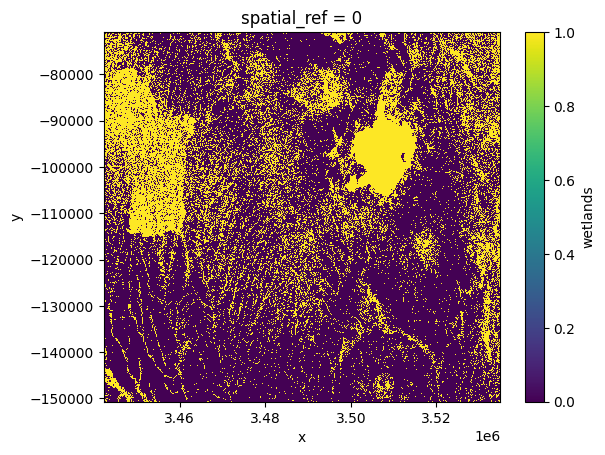

In [3]:
dea_wetlands = rioxarray.open_rasterio('data/Kenya_wetland_prediction_binary.tif').to_dataset('band').rename({1:'wetlands'}).rio.write_crs(6933, inplace=True)

dea_wetlands.wetlands.plot()

## 2. Binary vegetation layer

Vegetation later, fractional cover annual summary either photosynthetic (green) vegetation, or the combination of photosynthetic (green) and non-photosynthetic (non-green) vegetation.

Firstly, get configuration for fractional cover.

In [4]:
product_definition_yaml_url = f"https://explorer.digitalearth.africa/products/fc_ls_summary_annual.odc-product.yaml"
resp = requests.get(product_definition_yaml_url)
resp_text = resp.text

product_definition = yaml.load(resp_text, Loader=SafeLoader)

product_definition_measurements = product_definition['measurements']

assets_dict = {}
for measurement in product_definition_measurements:
    assets_dict[measurement['name']] = {'data_type': measurement['dtype'],
                                            'unit': measurement['units'],
                                            'nodata': measurement['nodata']}

fc_config = {"fc_ls_summary_annual": {"assets": assets_dict}}

fc_config

{'fc_ls_summary_annual': {'assets': {'pv_pc_10': {'data_type': 'uint8',
    'unit': 'percent',
    'nodata': 255},
   'pv_pc_50': {'data_type': 'uint8', 'unit': 'percent', 'nodata': 255},
   'pv_pc_90': {'data_type': 'uint8', 'unit': 'percent', 'nodata': 255},
   'bs_pc_10': {'data_type': 'uint8', 'unit': 'percent', 'nodata': 255},
   'bs_pc_50': {'data_type': 'uint8', 'unit': 'percent', 'nodata': 255},
   'bs_pc_90': {'data_type': 'uint8', 'unit': 'percent', 'nodata': 255},
   'npv_pc_10': {'data_type': 'uint8', 'unit': 'percent', 'nodata': 255},
   'npv_pc_50': {'data_type': 'uint8', 'unit': 'percent', 'nodata': 255},
   'npv_pc_90': {'data_type': 'uint8', 'unit': 'percent', 'nodata': 255},
   'count_valid': {'data_type': 'int16', 'unit': '1', 'nodata': 255},
   'qa': {'data_type': 'uint8', 'unit': '1', 'nodata': 255}}}}

### Set AWS Endpoint

In [5]:
configure_rio(
    cloud_defaults=True,
    aws={"aws_unsigned": True},
    AWS_S3_ENDPOINT="s3.af-south-1.amazonaws.com",
)

### Open the STAC catalog

In [6]:
# Open the stac catalogue
catalog = Client.open("https://explorer.digitalearth.africa/stac")

### Set area and period of interest

In [7]:
# Set a bounding box
# [xmin, ymin, xmax, ymax] in latitude and longitude
bbox = [35.6257, -1.2172, 36.6767, -0.5371]

# Set a start and end date
start_date = "2024-01-01"
end_date = "2024-12-31"

# Set the STAC collections
collections = ["fc_ls_summary_annual"]

In [8]:
# Build a query with the set parameters
query = catalog.search(
    bbox=bbox, collections=collections, datetime=f"{start_date}/{end_date}"
)

# Search the STAC catalog for all items matching the query
items = list(query.items())
print(f"Found: {len(items):d} datasets")

Found: 4 datasets


In [9]:
crs = "EPSG:6933"

ds_fc = stac_load(
    items,
    bands=("pv_pc_50"),
    like=dea_wetlands,
    chunks={},
    groupby="solar_day",
    stac_cfg=fc_config
).squeeze()

# View the Xarray Dataset
ds_fc

<xarray.Dataset> Size: 56MB
Dimensions:      (y: 3990, x: 4634)
Coordinates:
  * y            (y) float64 32kB -7.091e+04 -7.093e+04 ... -1.507e+05
  * x            (x) float64 37kB 3.442e+06 3.442e+06 ... 3.535e+06 3.535e+06
    spatial_ref  int32 4B 6933
    time         datetime64[ns] 8B 2024-01-01
Data variables:
    pv_pc_50     (y, x) uint8 18MB dask.array<chunksize=(3990, 4634), meta=np.ndarray>
    bs_pc_50     (y, x) uint8 18MB dask.array<chunksize=(3990, 4634), meta=np.ndarray>
    npv_pc_50    (y, x) uint8 18MB dask.array<chunksize=(3990, 4634), meta=np.ndarray>

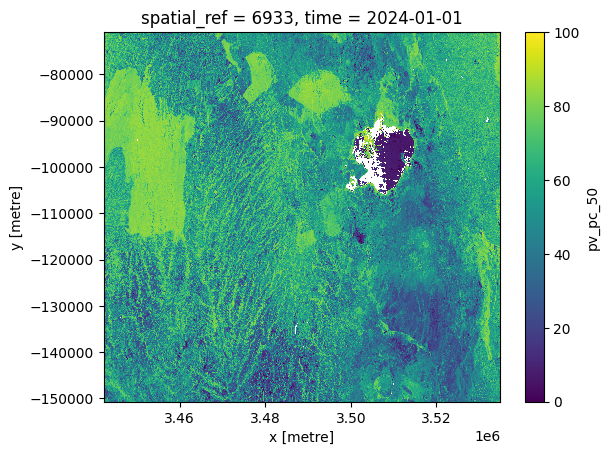

In [10]:
ds_fc = ds_fc.where(ds_fc.pv_pc_50 != 255)

### Threshold the vegetation layer

The cell below produces a binary layer where vegetation the median fraction of green vegetation in a pixel for the annual period is greater than the threshold value entered.

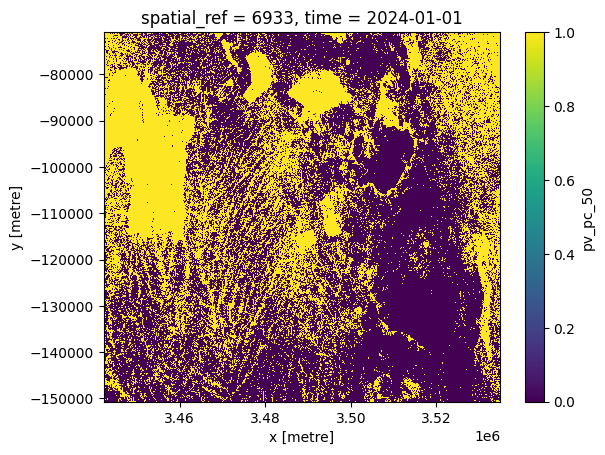

In [11]:
veg_thresh = 60

ds_veg = ds_fc.pv_pc_50.where(ds_fc.squeeze().pv_pc_50 > veg_thresh, 0) # create 0,1 binary layer
ds_veg = ds_veg.where(ds_veg == 0, 1)                                   # create 0,1 binary layer
ds_veg.plot()

## 2. Load water observations (WOfS)

Create binary mask for water observations.

In [12]:
wofs_config = get_product_config("wofs_ls_summary_annual", profile="deafrica")

In [13]:
collections = "wofs_ls_summary_annual"

# Build a query with the set parameters
query = catalog.search(
    bbox=bbox, collections=collections, datetime=f"{start_date}/{end_date}"
)

# Search the STAC catalog for all items matching the query
items = list(query.items())
print(f"Found: {len(items):d} datasets")

Found: 4 datasets


In [14]:
ds_wofs = stac_load(
    items,
    bands=("frequency"),
    like=dea_wetlands,
    chunks={},
    groupby="solar_day",
    stac_cfg=fc_config
).squeeze()

# View the Xarray Dataset
ds_wofs

<xarray.Dataset> Size: 74MB
Dimensions:      (y: 3990, x: 4634)
Coordinates:
  * y            (y) float64 32kB -7.091e+04 -7.093e+04 ... -1.507e+05
  * x            (x) float64 37kB 3.442e+06 3.442e+06 ... 3.535e+06 3.535e+06
    spatial_ref  int32 4B 6933
    time         datetime64[ns] 8B 2024-01-01
Data variables:
    frequency    (y, x) float32 74MB dask.array<chunksize=(3990, 4634), meta=np.ndarray>

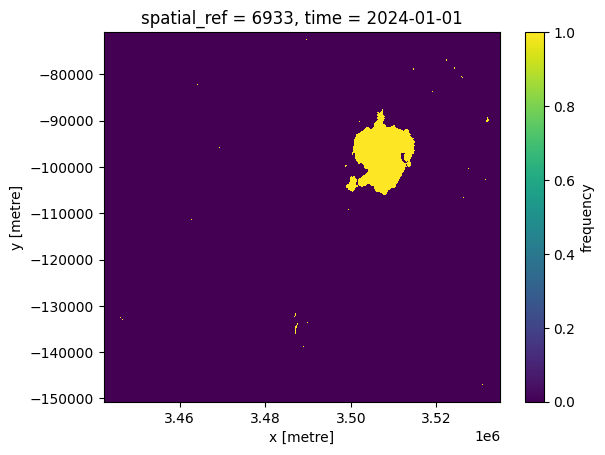

In [17]:
water_thresh = 0.6

ds_water = ds_wofs.frequency.where(ds_wofs.frequency > water_thresh, 0) # create 0,1 binary layer
ds_water = ds_water.where(ds_water == 0, 1)                             # create 0,1 binary layer
ds_water.plot()

## 3. Load cultivated layer

DE Africa cropland extent map.

In [18]:
cm_config = get_product_config("crop_mask", profile="deafrica")

In [20]:
collections = "crop_mask"

# Set a start and end date
start_date = "2019-01-01"                       # only 2019 is available
end_date = "2019-12-31"

# Build a query with the set parameters
query = catalog.search(
    bbox=bbox, collections=collections, datetime=f"{start_date}/{end_date}"
)

# Search the STAC catalog for all items matching the query
items = list(query.items())
print(f"Found: {len(items):d} datasets")

Found: 4 datasets


In [21]:
ds_cm = stac_load(
    items,
    bands=("mask"),
    like=dea_wetlands,
    chunks={},
    groupby="solar_day",
    stac_cfg=fc_config
).squeeze()

# View the Xarray Dataset
ds_cm

<xarray.Dataset> Size: 74MB
Dimensions:      (y: 3990, x: 4634)
Coordinates:
  * y            (y) float64 32kB -7.091e+04 -7.093e+04 ... -1.507e+05
  * x            (x) float64 37kB 3.442e+06 3.442e+06 ... 3.535e+06 3.535e+06
    spatial_ref  int32 4B 6933
    time         datetime64[ns] 8B 2019-01-01
Data variables:
    mask         (y, x) float32 74MB dask.array<chunksize=(3990, 4634), meta=np.ndarray>

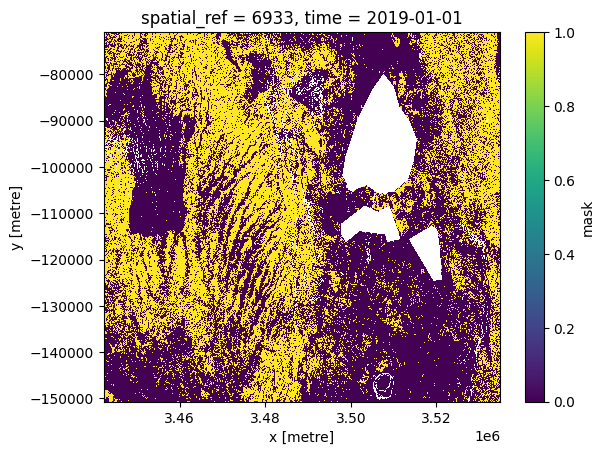

In [22]:
ds_cm.mask.plot()

## 4. Load World Settlement Footprint

Artificial surfaces layer.

In [23]:
wsf_config = get_product_config("wsf_2019", profile="deafrica")

In [24]:
collections = "wsf_2019"

# Build a query with the set parameters
query = catalog.search(
    bbox=bbox, collections=collections, datetime=f"{start_date}/{end_date}"
)

# Search the STAC catalog for all items matching the query
items = list(query.items())
print(f"Found: {len(items):d} datasets")

Found: 2 datasets


In [25]:
ds_wsf = stac_load(
    items,
    bands=("wsf2019"),
    like=dea_wetlands,
    chunks={},
    groupby="solar_day",
    stac_cfg=fc_config
).squeeze()

# View the Xarray Dataset
ds_wsf

<xarray.Dataset> Size: 74MB
Dimensions:      (y: 3990, x: 4634)
Coordinates:
  * y            (y) float64 32kB -7.091e+04 -7.093e+04 ... -1.507e+05
  * x            (x) float64 37kB 3.442e+06 3.442e+06 ... 3.535e+06 3.535e+06
    spatial_ref  int32 4B 6933
    time         datetime64[ns] 8B 2019-01-01
Data variables:
    wsf2019      (y, x) float32 74MB dask.array<chunksize=(3990, 4634), meta=np.ndarray>

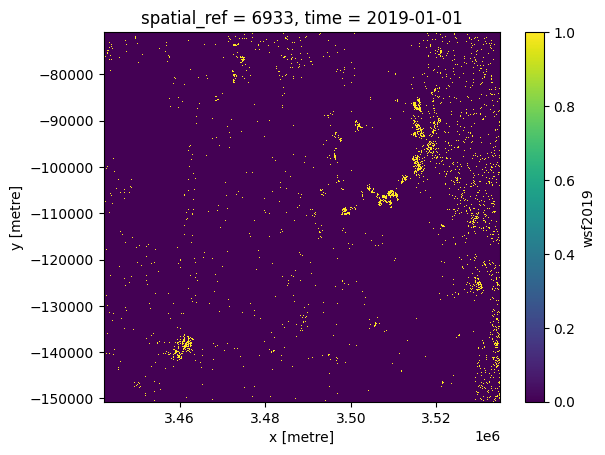

In [27]:
ds_wsf = ds_wsf.where(ds_wsf.wsf2019 == 0, 1)
ds_wsf.wsf2019.plot()

## 5. Combine layers

Merge layers together into a xarray object.

In [38]:
ds_layers = xr.merge([ds_veg, ds_water, ds_cm, ds_wsf], compat='override')

ds_layers

<xarray.Dataset> Size: 296MB
Dimensions:      (y: 3990, x: 4634)
Coordinates:
  * y            (y) float64 32kB -7.091e+04 -7.093e+04 ... -1.507e+05
  * x            (x) float64 37kB 3.442e+06 3.442e+06 ... 3.535e+06 3.535e+06
    spatial_ref  int32 4B 6933
    time         datetime64[ns] 8B 2024-01-01
Data variables:
    pv_pc_50     (y, x) float32 74MB dask.array<chunksize=(3990, 4634), meta=np.ndarray>
    frequency    (y, x) float32 74MB dask.array<chunksize=(3990, 4634), meta=np.ndarray>
    mask         (y, x) float32 74MB dask.array<chunksize=(3990, 4634), meta=np.ndarray>
    wsf2019      (y, x) float32 74MB dask.array<chunksize=(3990, 4634), meta=np.ndarray>
Attributes:
    nodata:   255